In [1]:
import visualkeras
import tensorflow as tf

In [ ]:
model =  tf.keras.models.load_model("../models/inference_model.keras")  # Update path

visualkeras.layered_view(model).show() # display using your system viewer
#visualkeras.layered_view(model, to_file='output.png') # write to disk
#visualkeras.layered_view(model, to_file='output.png').show() # write and show

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 26 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


In [3]:
def text_callable(layer_index, layer):
    # Every other piece of text is drawn above the layer, the first one below
    above = bool(layer_index % 2)

    # Get the output shape safely
    if hasattr(layer, 'output_shape'):
        # Legacy Keras / older TF
        output_shape = [x for x in layer.output.shape if x is not None]
    else:
        # Modern TF-Keras >= 2.11
        shape = layer.output.shape
        if hasattr(shape, 'as_list'):
            output_shape = [x for x in shape.as_list() if x is not None]
        else:
            output_shape = [x for x in shape if x is not None]  # tuple fallback

    # If output_shape is a list of tuples (like multi-output), take the first
    if isinstance(output_shape[0], tuple):
        output_shape = [x for x in output_shape[0] if x is not None]

    # Build text string
    output_shape_txt = ""
    for ii in range(len(output_shape)):
        output_shape_txt += str(output_shape[ii])
        if ii < len(output_shape) - 2:  # x between dimensions
            output_shape_txt += "x"
        if ii == len(output_shape) - 2:  # newline between last two dims
            output_shape_txt += "\n"

    output_shape_txt += f"\n{layer.name}"

    return output_shape_txt, above


In [4]:
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D, ZeroPadding2D

from collections import defaultdict

color_map = defaultdict(dict)

color_map[Conv2D]['fill'] = '#87CEEB'      # Sky Blue
color_map[ZeroPadding2D]['fill'] = '#FFE4C4' # Soft sandy beige
color_map[Dropout]['fill'] = '#FF7F50'     # Coral
color_map[MaxPooling2D]['fill'] = '#00FA9A' # Fresh Lime
color_map[Dense]['fill'] = '#32CD32'       # Lime Green
color_map[Flatten]['fill'] = '#BA55D3'     # Medium orchid / subtle purple


In [5]:
print(color_map)

defaultdict(<class 'dict'>, {<class 'keras.src.layers.convolutional.conv2d.Conv2D'>: {'fill': '#87CEEB'}, <class 'keras.src.layers.reshaping.zero_padding2d.ZeroPadding2D'>: {'fill': '#FFE4C4'}, <class 'keras.src.layers.regularization.dropout.Dropout'>: {'fill': '#FF7F50'}, <class 'keras.src.layers.pooling.max_pooling2d.MaxPooling2D'>: {'fill': '#00FA9A'}, <class 'keras.src.layers.core.dense.Dense'>: {'fill': '#32CD32'}, <class 'keras.src.layers.reshaping.flatten.Flatten'>: {'fill': '#BA55D3'}})


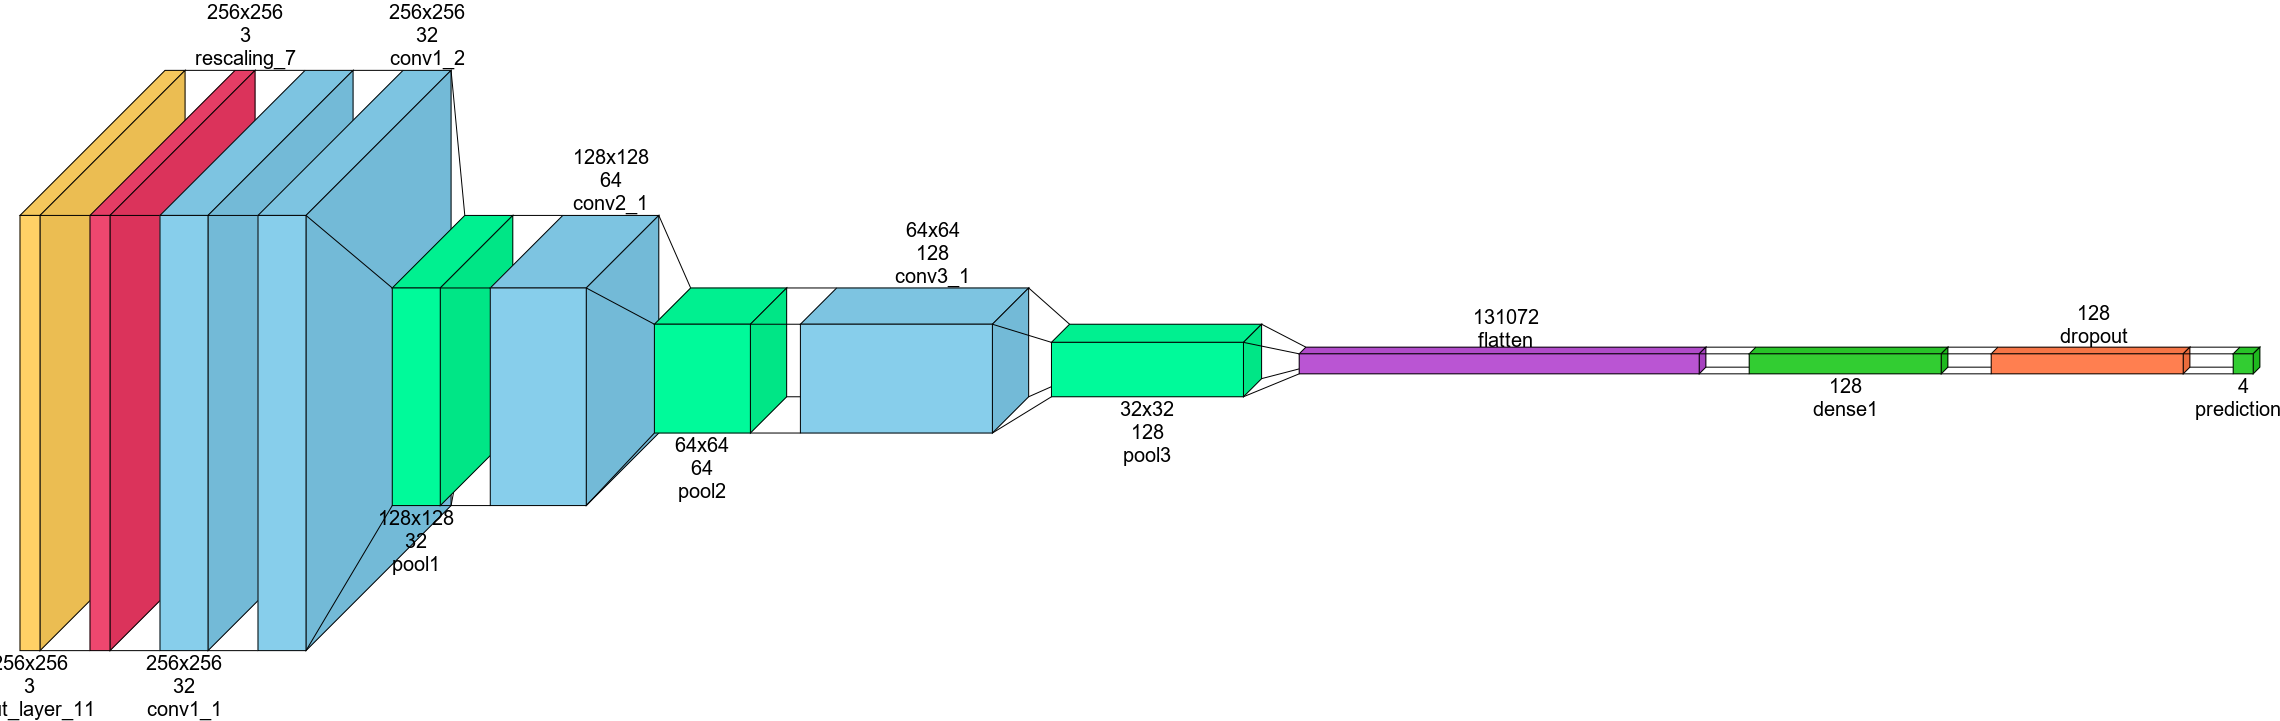

In [6]:
from PIL import ImageFont

font = ImageFont.truetype("arial.ttf", 20)  # using comic sans is strictly prohibited! (just joking)
visualkeras.layered_view(model, padding = 20, font=font, scale_xy= 1.7, scale_z=1.5, spacing = 50, text_callable=text_callable, color_map=color_map)  # font is optional!